
# importación de librerias

In [21]:
from pandas import read_csv
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np


# Parte #1

## Importación de datos

In [22]:
S = read_csv('Datos\Lampara_con_muestra.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python')
D = read_csv('Datos\Lampara_apagada.csv',delimiter = ';', skiprows = 32, skipfooter=2,engine='python')
R = read_csv('Datos\Lampara_sin_muestra.csv',delimiter = ';', skiprows = 32, skipfooter=2, engine='python')
B = read_csv('Datos\ThorBB2000.csv',delimiter = ';', skiprows = 69,skipfooter=2, engine='python')

<>:1: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\T'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11060\2352359115.py:1: SyntaxWarning: invalid escape sequence '\L'
  S = read_csv('Datos\Lampara_con_muestra.csv', delimiter= ';', skiprows = 32, skipfooter=2, engine='python')
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11060\2352359115.py:2: SyntaxWarning: invalid escape sequence '\L'
  D = read_csv('Datos\Lampara_apagada.csv',delimiter = ';', skiprows = 32, skipfooter=2,engine='python')
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11060\2352359115.py:3: SyntaxWarning: invalid escape sequence '\L'
  R = read_csv('Datos\Lampara_sin_muestra.csv'

In [23]:

L = S.index.to_numpy() #convertimos a array los datos de las longitudes de onda
S = S['[Data]'].to_numpy()#convertimos a array los datos de las intensidades
R = R['[Data]'].to_numpy()
D = D['[Data]'].to_numpy()
B = B['[Data]'].to_numpy()
I = B * ((S - D)/(R - D))#Calculo del espectro de irradiancia de la lámpara



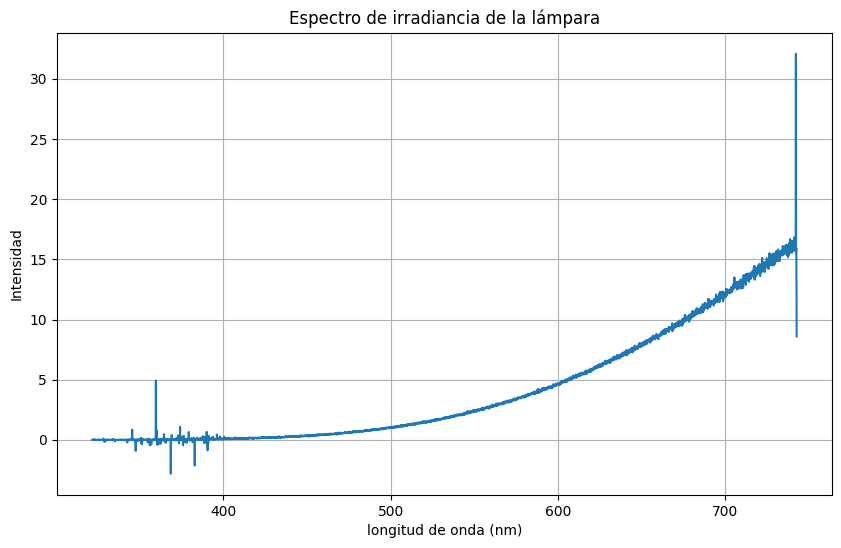

In [24]:
#Gráfica de la intensidad del espectro de irradidancia
plt.figure(figsize=(10,6))
plt.title("Espectro de irradiancia de la lámpara")
plt.plot(L, I*1e9)
plt.ylabel("Intensidad")
plt.xlabel("longitud de onda (nm)")
plt.grid()
plt.show()


In [ ]:
#función exponencial que será usada para el ajuste

def fL (l, a,b):
    '''Esta función realiza un ajuste a la potencia
    por unidad de area para el espectro de irradiancia
    
    Parámetros:
    a : parámetro de ajuste
    b : parámetro de ajuste
    l: longitud de onda, variable independiente
    
    Salidas: 
    funcion del espectro de irradiancia en función de la 
    longitud de onda.
    '''

    return a * 1/(l**5 *(np.exp(b/l)-1))

In [26]:
par, cov = curve_fit(fL, L, I)

<>:11: SyntaxWarning: invalid escape sequence '\I'
<>:11: SyntaxWarning: invalid escape sequence '\I'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11060\1316803377.py:11: SyntaxWarning: invalid escape sequence '\I'
  plt.savefig('Articulo\Imagenes\Ajuste_de_ley_de_planck.png')


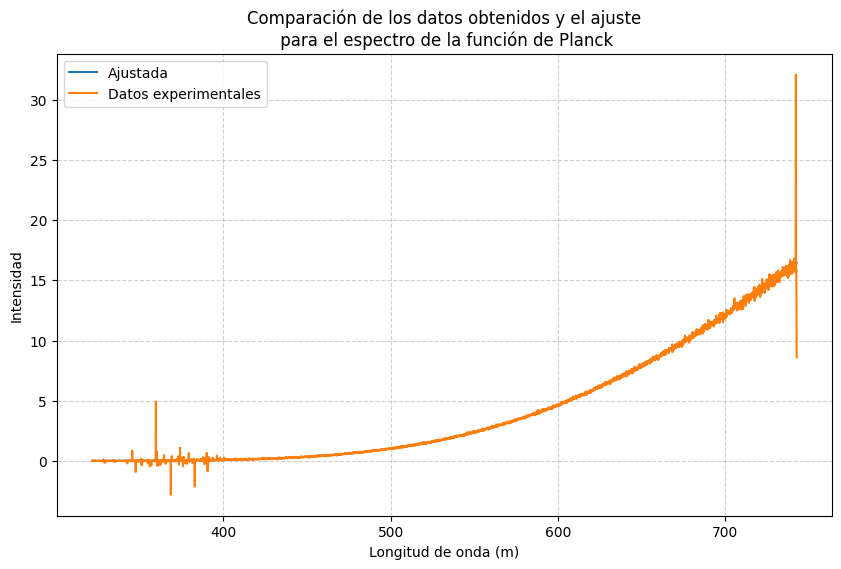

In [34]:
a = par[0]
b = par[1]
plt.figure(figsize = (10,6))
plt.title("Comparación de los datos obtenidos y el ajuste\n para " \
"el espectro de la función de Planck")
plt.plot(L, fL(L,a,b)*1e9, label = 'Ajustada')
plt.plot(L, I*1e9, label = 'Datos experimentales')
plt.legend()
plt.xlabel("Longitud de onda (m)")
plt.ylabel("Intensidad")
plt.savefig('Articulo\Imagenes\Ajuste_de_ley_de_planck.png')
plt.grid(alpha = 0.6, linestyle = '--')
plt.show()


## Chi cuadrado

# Parte #2